<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src=attachment:ad91936b-ffaa-4d78-8fca-1b445a35e3cd.jpg alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---

# <h1><center>Interrogación 2</center></h1>

## Instrucciones

* Esta parte de la Interrogación debe ser desarrollada completamente en lenguaje de programación Python en este Notebook de Jupyter.

* El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados, y siguiendo buenas prácticas de programación. <br>
* La entrega de la interrogación se realizará a través de Canvas en la actividad `I2 Desarrollo`.
* Esta Interrogación debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
* Está **estrictamente prohibido comunicarse con sus compañeros de curso, terceras personas o uso de IA** durante el desarrollo de esta interrogación.
* Puede consultar los apuntes del curso y soluciones disponibles en el repositorio del ramo.
* Habrá sólo dos instancias para hacer preguntas, una al inicio de la prueba y otra a los 30 minutos de avance.<br>


* Ud. dispone de 1 hora para desarrollar esta interrogación.
* Recuerde **guardar frecuentemente sus avances** para evitar pérdidas de trabajo o problemas de envío.<br>
---

## Parte 2: Trabajo de Desarrollo (60 min)

Esta parte de la Interrogación es un trabajo práctico con datos. En esta parte, cada pregunta debe ser respondida desarrollando un código por usted que le permita entregar una respuesta.

En esta sección, estaremos trabajando con dos bases de datos. En primer lugar, usaremos los registros de la Organización Mundial de la Salud (OMS) de las espectativas de vida en distintos países a través de los años (Disponible desde la [página web de la OMS](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))) En segundo lugar, utilizaremos los datos de producto interno bruto (PIB) de distintos países (Disponible desde [Kaggle](https://www.kaggle.com/datasets/codebynadiia/gdp-per-country-20202025)).

Nuestro objetivo será explorar y analizar el comportamiento de estos datos, comprendiendo la relación entre estas dos variables, para finalmente entrenar modelos de regresión y evaluar su desempeño.

## 1. Lectura, limpieza y transformación (20 pts)

### 1.1 Lectura e inspección inicial (5 pts)
Usted dispone de los siguientes archivos:
* `pib2020-2025.csv`: contiene información del PIB en mil millones de USD de varios países entre los años 2020 y 2025.
* `WHO_life_expectancy.csv`: dataset de la OMS que contiene información sobre la espectativa de vida en varios países y años.

Para comenzar, cargue los dos archivos en dos dataframes separados llamados `pib_df`y `life_df`, respectivamente. Para cada uno, imprima la cantidad de filas que tiene, las columnas y sus tipos, y las primeras 5 filas.

In [18]:
# agregue las librerías que crea necesarios. Acá dejamos algunas estánadar que podrían ser de ayuda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# respuestas
WHO_life = pd.read_csv('data_2025\\WHO_life_expectancy.csv')
pib2020_2025 = pd.read_csv('data_2025\\pib2020-2025.csv')

In [20]:
print(f"WHO Life \nFilas {WHO_life.shape[0]}, Columnas : {WHO_life.shape[1]}")
print(WHO_life.columns)
print("")
print(f"pib2020_2025 \nFilas {pib2020_2025.shape[0]}, Columnas : {pib2020_2025.shape[1]}")
print(pib2020_2025.columns)

WHO Life 
Filas 24420, Columnas : 12
Index(['IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation',
       'Location type', 'SpatialDimValueCode', 'Location', 'Period type',
       'Period', 'Dim1 type', 'Dim1', 'Value'],
      dtype='object')

pib2020_2025 
Filas 196, Columnas : 7
Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')


In [21]:
WHO_life.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [22]:
pib2020_2025.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


### 1.2 Limpieza de datos PIB (5 pts)

* Asegúrese de que su DataFrame `pib_df` no contenga valores nulos.
* Identifique si hay datos duplicados y elimínelos.
* Corrija los tipos de las columnas según corresponda, siempre justificando sus decisiones.

In [27]:
# respuestas
pib_df = pib2020_2025.copy()
#print(pib_df.duplicated().sum()) #np.int64(0)
#print(pib2020_2025.isnull().sum())
'''
Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64
'''
pib_df = pib_df.dropna()
pib_df.isnull().sum()


Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
dtype: int64

### 1.3 Filtrar datos de `life_df` (5 pts)

Esta vez, solo usaremos los valores de **espectativa de vida al nacer** para cada país según sexo.
Inspeccione su DataFrame y realice los siguientes pasos:

1. Elimine todas las filas que no correspondan a espectativas de vida al nacer.
2. Elimine todas las columnas que considere innecesarias. Justifique su elección.

In [40]:
# respuestas
life_df = WHO_life.copy()
#life_df.columns

life_df["Indicator"].unique()

life_df = life_df[life_df["Indicator"] == "Life expectancy at birth (years)"]
life_df["Indicator"].unique()

array(['Life expectancy at birth (years)'], dtype=object)

In [41]:
life_df.columns

Index(['IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation',
       'Location type', 'SpatialDimValueCode', 'Location', 'Period type',
       'Period', 'Dim1 type', 'Dim1', 'Value'],
      dtype='object')

In [42]:
life_df = life_df[["IndicatorCode", "ParentLocationCode", "ParentLocation", "SpatialDimValueCode", "Location", "Period", "Dim1", "Value"]]
life_df

,IndicatorCode,ParentLocationCode,ParentLocation,SpatialDimValueCode,Location,Period,Dim1,Value
0,WHOSIS_000001,AFR,Africa,LSO,Lesotho,2021,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,AFR,Africa,CAF,Central African Republic,2021,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,AFR,Africa,LSO,Lesotho,2021,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,AFR,Africa,SWZ,Eswatini,2021,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,EMR,Eastern Mediterranean,SOM,Somalia,2021,Male,51.7 [50.6-53.1]
...,...,...,...,...,...,...,...,...
23860,WHOSIS_000001,WPR,Western Pacific,AUS,Australia,2000,Female,82.2 [82.2-82.3]
23861,WHOSIS_000001,EUR,Europe,CHE,Switzerland,2000,Female,82.3 [82.3-82.4]
23862,WHOSIS_000001,EUR,Europe,ESP,Spain,2000,Female,82.5 [82.4-82.5]
23863,WHOSIS_000001,EUR,Europe,FRA,France,2000,Female,82.5 [82.5-82.6]


Borre las columnas 

Period type ya que en todo el csv solo hay 1 tipo de periodo de tiempo 

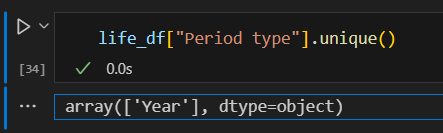

Dim1 type ya que en todo el csv solo hay 1 tipo de dim1 

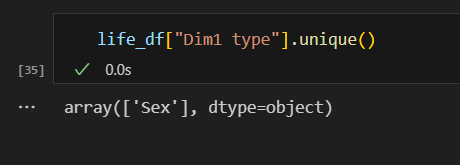

Location type por la misma razon que las 2

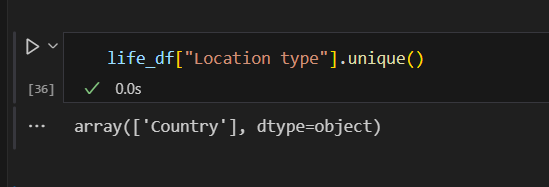

Indicator ya que sabemos previamente que siempre sera 'Life expectancy at birth (years)'

### 1.4 Transformar valores de `life_df` (5 pts)

Podrá haber notado que la columna `Value` es un string de formato `n1 [n2-n3]`, donde `n1` es el valor promedio de la variable, mientras que `n2`y `n3` son los límites inferior y superior de la variable. Para nuestro análisis, solo nos interesa el valor promedio.

* Transforme la columna `Value` para que solo contenga el valor promedio (`n1`). Asegúrese de que el tipo de columna sea siempre el correcto.
* Imprima los estadísticos principales de esta columna (promedio, desviación estándar, mínimo y máximo, etc)


In [ ]:
# respuestas

life_df['Value_num'] = life_df['Value'].str.split().str[0].astype(float)


In [45]:
life_df.describe()

,Period,Value_num
count,12210.000000,12210.000000
mean,2010.500000,70.174914
std,6.344549,8.899653
min,2000.000000,36.600000
25%,2005.000000,64.200000
50%,2010.500000,71.900000
75%,2016.000000,77.100000
max,2021.000000,87.400000


## 2. EDA univariado (27 pts)

Procederemos a explorar los datos contenidos dentro de `pib_df` y `life_df` por separado. Responda las siguientes preguntas, apoyándose de un gráfico cuando se le indique. No olvide colocar un título claro y etiquetas a los ejes de sus gráficos.

### 2.1 Valores del PIB (12 pts)

* ¿Entre qué magnitudes de valores se mueve el PIB de los países del mundo desde el año 2020 hasta 2025?
* ¿Cuáles son los 3 países con mayor PIB en 2025?
* ¿Cuáles son los 3 países con menor PIB en 2021?
* Seleccione un año de los disponibles y realice un histograma de los valores del PIB para ese año. ¿Cómo se distribuye esta variable? Comente.

In [78]:
#Respuesta 1
print("min/max-2020",pib_df["2020"].min(),pib_df["2020"].max()) 
print("min/max-2021",pib_df["2021"].min(),pib_df["2021"].max()) 
print("min/max-2022",pib_df["2022"].min(),pib_df["2022"].max()) 
print("min/max-2023",pib_df["2023"].min(),pib_df["2023"].max()) 
print("min/max-2024",pib_df["2024"].min(),pib_df["2024"].max()) 
print("min/max-2025",pib_df["2025"].min(),pib_df["2025"].max()) 

# Basicamente

min/max-2020 52 21354125
min/max-2021 62.0 23681175.0
min/max-2022 61.0 26006900.0
min/max-2023 63.0 27720725.0
min/max-2024 65.0 29184900.0
min/max-2025 65.0 30507217.0


In [ ]:
#Respuesta 2
#pib_df.head()
pib_df[["Country","2025"]].sort_values("2025", ascending=False)

,Country,2025
186,United States,30507217.0
36,China,19231705.0
64,Germany,4744804.0
77,India,4187017.0
85,Japan,4186431.0
...,...,...
132,Palau,333.0
89,Kiribati,312.0
109,Marshall Islands,297.0
121,Nauru,169.0


In [ ]:
#Respuesta 3
pib_df[["Country","2021"]].sort_values("2021", ascending=False)

,Country,2021
186,United States,23681175.0
36,China,18190803.0
85,Japan,5039148.0
64,Germany,4351188.0
77,India,3167271.0
...,...,...
89,Kiribati,285.0
109,Marshall Islands,259.0
132,Palau,236.0
121,Nauru,176.0


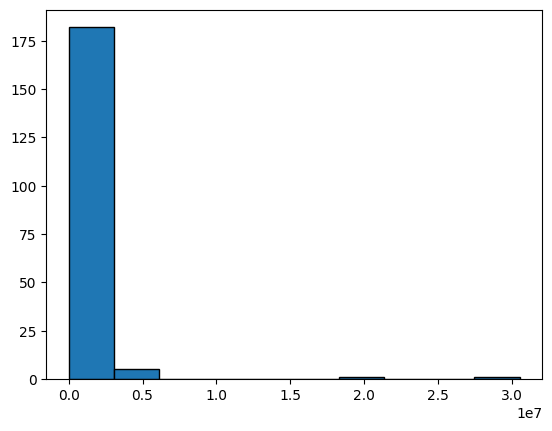

In [ ]:
#Respuesta 4
plt.hist(pib_df["2025"], edgecolor='black')
plt.show()

En el histograma podemos apreciar que se distribuyen de que la gran mayoria esta concentrada en la parte izquierda, es decir un pib bajo

### 2.2 Esperanzas de vida (15 pts)

* ¿Cuántos países distintos hay representados dentro de `life_df`?
* ¿Cuál es el rango de años que contiene el dataset? ¿Cuáles de estos coinciden con los años que tenemos en `pib_df`?
* El dataset de la OMS le asigna un `ParentLocation` a cada país. Imprima todos los posibles valores y cuántas veces se repiten en su dataset `life_df`. ¿Cómo interpreta estas cantidades?
* Realice un boxplot que muestre la esperanza de vida según sexo y continente (o sector `ParentLocation`). Puede realizar uno o dos gráficos. Realice esta visualización solamente con los datos de 2021.

In [86]:
# Respuesta 1
contador = 0
for i in life_df["Location"].unique():
    contador+= 1
print("Dentro de life_df hay",{contador}, "paises")

Dentro de life_df hay {185} paises


In [91]:
#respuesta 2
(life_df["Period"].unique())

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000])

#respuesta 2.2 2)
Hay un total de 22 de los cuales se coincide desde 2020 a 2021


In [106]:
#Respuesta 3)
print(life_df["ParentLocation"].unique())

print()
Africa =life_df[life_df["ParentLocation"] == "Africa"]
print("Africa cant duplicados",Africa["ParentLocation"].duplicated().sum())

Eas =life_df[life_df["ParentLocation"] == "Eastern Mediterranean"]
print("Eastern Mediterranean cant duplicados",Eas["ParentLocation"].duplicated().sum())

Wes =life_df[life_df["ParentLocation"] == "Western Pacific"]
print("Western Pacific cant duplicados",Wes["ParentLocation"].duplicated().sum())

Americas =life_df[life_df["ParentLocation"] == "Americas"]
print("Americas cant duplicados",Americas["ParentLocation"].duplicated().sum())

SOEaAsia =life_df[life_df["ParentLocation"] == "South-East Asia"]
print("South-East Asia cant duplicados",SOEaAsia["ParentLocation"].duplicated().sum())

Europe =life_df[life_df
                ["ParentLocation"] == "Europe"]
print("Europe cant duplicados",Europe["ParentLocation"].duplicated().sum())

['Africa' 'Eastern Mediterranean' 'Western Pacific' 'Americas'
 'South-East Asia' 'Europe']

Africa cant duplicados 3101
Eastern Mediterranean cant duplicados 1451
Western Pacific cant duplicados 1385
Americas cant duplicados 2243
South-East Asia cant duplicados 725
Europe cant duplicados 3299


Respuesta 3, yo interpreto esto como lo que es, en Europa hay mas datos simplemente y que hay un mayor % de espectativa de vida, aun que esto no lo puedo confirmar, solo lo puedo hacer al revisar Values

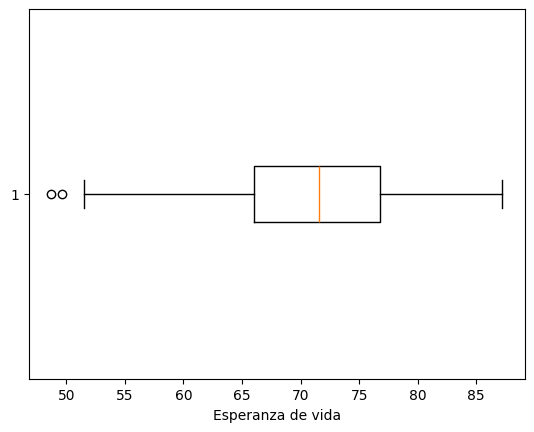

In [121]:
life_df_2021 = life_df.copy()
life_df_2021 = life_df_2021[life_df_2021["Period"] == 2021]

plt.boxplot(life_df_2021['Value_num'], vert=False)
plt.xlabel('Esperanza de vida')
plt.show()

Respuestas:

## 3. EDA multivariado (10 pts)

Ahora queremos entender la relación entre las variables del PIB y la esperanza de vida al nacer. Genere un único dataframe llamado `full_df` a partir de los dos datasets anteriores y responda las siguientes preguntas. De aquí en adelante, vamos a considerar **solamente** la esperanza de vida calculada para ambos sexos (Both sexes).

* ¿Cuál es la correlación entre el PIB de un país con la esperanza de vida al nacer? Calcule el valor para los años 2020 y 2021. ¿Qué nos indica este valor?

* Realice un scatterplot donde su eje X represente la esperanza de vida y su eje Y, el PIB. Comente lo que observa.

In [149]:
# respuestas
a = pib_df.copy()
b = life_df.copy()
b = b.rename(columns={'Location':'Country'})
b.columns

mergeado = pd.merge(a, b, on= 'Country', how='inner')
mergeado_bothsexes = mergeado[mergeado["Dim1"]=="Both sexes"]
#mergeado_bothsexes.head()
#print(mergeado_bothsexes.columns)

corr_2020 = mergeado_bothsexes[mergeado_bothsexes["Period"] == 2020][["2020", "Value_num"]].corr()
print("Correlación 2020:\n", corr_2020)

corr_2021 = mergeado_bothsexes[mergeado_bothsexes["Period"] == 2021][["2021", "Value_num"]].corr()
print("Correlación 2020:\n", corr_2020)



Correlación 2020:
                2020  Value_num
2020       1.000000   0.216956
Value_num  0.216956   1.000000
Correlación 2020:
                2020  Value_num
2020       1.000000   0.216956
Value_num  0.216956   1.000000


#Respuesta 1:
enen ambos casos tienen una correlacion parecida, y ademas en ambas es bien baja, un 0.21%  por lo que no tienen mucha correlacion

ValueError: x and y must be the same size

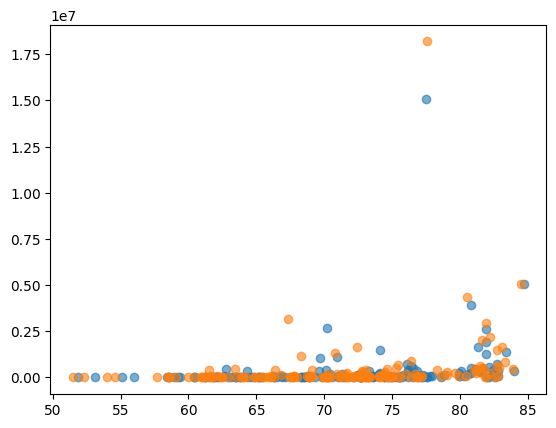

In [152]:
p2020= mergeado_bothsexes[mergeado_bothsexes["Period"] == 2020]
p2021 = mergeado_bothsexes[mergeado_bothsexes["Period"] == 2021]
p2022= mergeado_bothsexes[mergeado_bothsexes["Period"] == 2022]
p2023= mergeado_bothsexes[mergeado_bothsexes["Period"] == 2023]
p2024= mergeado_bothsexes[mergeado_bothsexes["Period"] == 2024]
p2025= mergeado_bothsexes[mergeado_bothsexes["Period"] == 2025]
plt.scatter(p2020["Value_num"], p2021["2020"],alpha=0.6)
plt.scatter(p2021["Value_num"], p2021["2021"],alpha=0.6)
plt.scatter(p2022["Value_num"], p2021["2022"],alpha=0.6)
plt.scatter(p2023["Value_num"], p2021["2023"], alpha=0.6)

plt.show()

## 4. Transformación de escala (15 pts)

Ahora vamos a transformar la escala de nuestras variables para visualizar mejor la relación entre la espectativa de vida y PIB de los países.

* Genere las columnas `logPIB 2020` y `logPIB 2021`, donde el valor de cada columna corresponde al logaritmo en base 10 del PIB original. (Por ejemplo, si un valor de la columna `2020` es $x$, el valor correspondiente en la columna `logPIB 2020` debe ser $log_{10}(x)$

* Calcule nuevamente la correlación entre el PIB y la esperanza de vida al nacer para los dos años mencionados.

* Ahora, genere nuevamente un scatterplot entre la espectativa de vida promedio al nacer y su nueva representación del PIB para los años 2020 y 2021 por separado. ¿Puede ver alguna relación entre estas variables? Comente sus resultados.

In [ ]:
# respuestas

## 5. Regresiones (28 pts)

Finalmente entrenaremos algunos modelos de regresión. Vamos a comparar el desempeño entre una regresión lineal y una **regresión logarítmica**, donde el valor a predecir ($y$), será calculado como:
$$ y = \beta_0 + \beta_1 \cdot log_{10}(X)$$

donde $X$ será nuestro PIB, $y$ corresponderá a la espectativa de vida al nacer y $\beta_0, \beta_1$ los coeficientes que calculará nuestro modelo.

En la práctica, vamos a partir realizando dos **regresión lineales**: la primera con la variable del PIB original y la segunda con nuestras nuevas columnas `logPIB` como nuestro $X$. 

En la siguiente sección, trabaje solamente con las esperanzas de vida de ambos sexos calculadas el año 2021.

In [ ]:
# acá dejamos algunas librerías que pueden ser de utilidad, pero pueden agregar otras.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error as rmse
from sklearn.preprocessing import PolynomialFeatures

#### 5.1 Cree la matriz $X_1$ (PIB 2020 y 2021) y $X_2$ (log PIB 2020 y 2021), junto con el vector **y**. Luego separe cada uno en conjunto de entrenamiento y prueba con una división 70-30. (5 pts)
(Asigne explícitamente un valor a `random_state` para que su respuesta sea reproducible.)

In [ ]:
# respuestas

#### 5.2 Entrene un modelo de regresión lineal para $X_1$. Imprima los coeficientes encontrados y calcule el RMSE y el $r^2$ para los conjuntos de entrenamiento y prueba. ¿Es una buena regresión? (10 pts)

In [ ]:
# respuestas

Respuestas:

#### 5.3 Repita el proceso, esta vez para $X_2$. ¿Cómo se compara con la anterior? (6 pts)

In [ ]:
# respuestas

Respuestas:

#### 5.4 Elija la variable con la que mejor desempeño obtuvo y entrene un modelo de regresión "polinomial" de grado 2, 3 y 4 con ella. Calcule nuevamente el RMSE y el $r^2$ para ambos conjuntos. ¿Mejoró su resultado? De todos los modelos, ¿cuál eligiría? (7 pts)

In [ ]:
# respuestas

Respuestas: